_Neural Data Science_

Lecturer: Prof. Dr. Philipp Berens, Dr. Jan Lause

Tutors: Jonas Beck, Kyra Kadhim, Jonathan Oesterle, Julius Würzler

Summer term 2026

Student names: <span style='background: maroon'>*Jiseok Ryu,  Arlette Musanabera* </span>

LLM Disclaimer: <span style='background: yellow'>*We used Claude for some Interpreations of Results* </span>

# Coding Lab 2

## Introduction

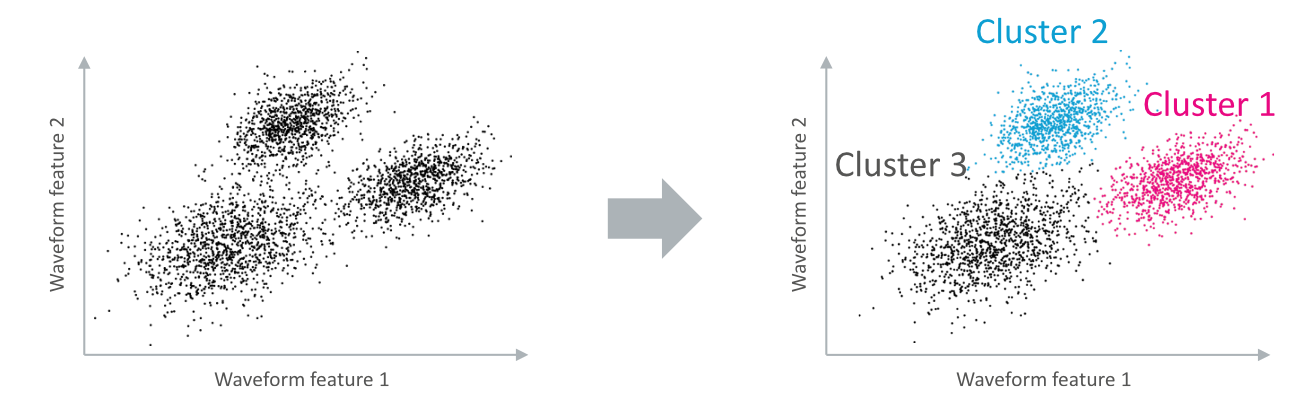

In this coding lab, we continue with the data from the first coding lab and finalize the Spike Sorting pipeline.
In particular, we use the created feature space to identify individual clusters by fitting a Gaussian Mixture Model.
To verify that this model does what we want, we first create a synthetic Toy Dataset and apply the model to that.

- __Data__: Use the saved data `nds_cl_1_*.npy` from Coding Lab 1. Or, if needed, download the data files ```nds_cl_1_*.npy``` from ILIAS and save it in the subfolder ```../data/```.
- __Dependencies__: You don't have to use the exact versions of all the dependencies in this notebook, as long as they are new enough. But if you run "Run All" in Jupyter and the boilerplate code breaks, you probably need to upgrade them.

In [30]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from __future__ import annotations

%load_ext jupyter_black

%load_ext watermark
%watermark --time --date --timezone --updated --python --iversions --watermark -p sklearn

The jupyter_black extension is already loaded. To reload it, use:
  %reload_ext jupyter_black
The watermark extension is already loaded. To reload it, use:
  %reload_ext watermark
Last updated: 2026-04-29 20:25:34 SAST

Python implementation: CPython
Python version       : 3.10.0
IPython version      : 8.39.0

sklearn: 1.7.2

matplotlib: 3.10.8
numpy     : 2.2.6
scipy     : 1.15.3
sklearn   : 1.7.2

Watermark: 2.6.0



In [31]:
plt.style.use("../matplotlib_style.txt")

## Load data

In [32]:
# replace by path to your solutions
b = np.load("../data/nds_cl_1_features.npy")
s = np.load("../data/nds_cl_1_spiketimes_s.npy")
t = np.load("../data/nds_cl_1_spiketimes_t.npy")
w = np.load("../data/nds_cl_1_waveforms.npy")

## Task 1: Generate toy data

Sample 1000 data points from a two dimensional mixture of Gaussian model with three clusters  and the following parameters:

$\mu_1 = \begin{bmatrix}0\\0\end{bmatrix}, \Sigma_1 = \begin{bmatrix}1 & 0\\0 & 1\end{bmatrix}, \pi_1=0.3$

$\mu_2 = \begin{bmatrix}5\\1\end{bmatrix}, \Sigma_2 = \begin{bmatrix}2 & 1\\1 & 2\end{bmatrix}, \pi_2=0.5$

$\mu_3 = \begin{bmatrix}0\\4\end{bmatrix}, \Sigma_3 = \begin{bmatrix}1 & -0.5\\-0.5 & 1\end{bmatrix}, \pi_3=0.2$

Plot the sampled data points and indicate in color the cluster each point came from. Plot the cluster means as well.

*Grading: 2 pts*


In [33]:
def sample_data(
    n_samples: int, m: np.ndarray, S: np.ndarray, p: np.ndarray, random_seed: int = 0
) -> tuple[np.ndarray, np.ndarray]:
    """Generate n_samples samples from a Mixture of Gaussian distribution with
    means m, covariances S and priors p.

    Parameters
    ----------

    n_samples: int
        Number of samples

    m: np.ndarray, (n_clusters, n_dims)
        Means

    S: np.ndarray, (n_clusters, n_dims, n_dims)
        Covariances

    p: np.ndarray, (n_clusters, )
        Cluster weights / probablities

    random_seed: int
        Random Seed

    Returns
    -------

    labels: np.array, (n_samples, )
        Grund truth labels.

    x: np.array, (n_samples, n_dims)
        Data points
    """
    # ensure reproducibility using a random number generator
    # hint: access random functions of this generator
    rng = np.random.default_rng(random_seed)

    # ------------------------------------------------------
    # draw labeled points from mixture of Gaussians (1 pt)
    # ------------------------------------------------------
    n_clusters = m.shape[0]
    n_dims = m.shape[1]

    # choose which cluster each point comes from
    labels = rng.choice(n_clusters, size=n_samples, p=p)

    # create empty array for data
    x = np.zeros((n_samples, n_dims))

    # sample from the corresponding Gaussian for each cluster
    for k in range(n_clusters):
        idx = labels == k
        n_k = np.sum(idx)

        x[idx] = rng.multivariate_normal(mean=m[k], cov=S[k], size=n_k)

    return labels, x

In [34]:
N = 1000  # total number of samples

p = np.array([0.3, 0.5, 0.2])  # percentage of each cluster
m = np.array([[0.0, 0.0], [5.0, 1.0], [0.0, 4.0]])  # means

S1 = np.array([[1.0, 0.0], [0.0, 1.0]])
S2 = np.array([[2.0, 1.0], [1.0, 2.0]])
S3 = np.array([[1.0, -0.5], [-0.5, 1.0]])
S = np.stack([S1, S2, S3])  # cov

labels, x = sample_data(N, m, S, p, random_seed=2605)

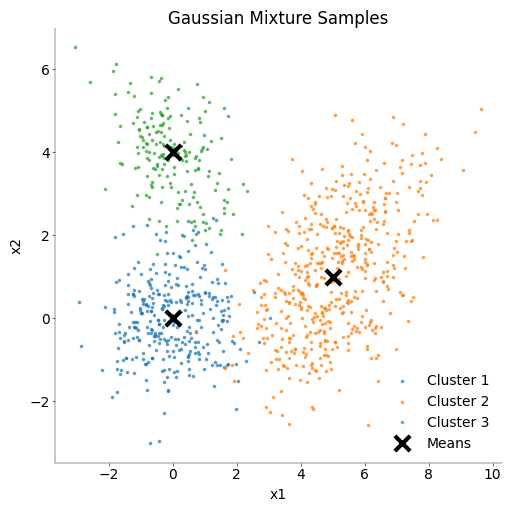

In [35]:
# ----------------------------------------------
# plot points from mixture of Gaussians (1 pt)
# ----------------------------------------------

fig, ax = plt.subplots(figsize=(5, 5), layout="constrained")

# plot each cluster with different color
for k in range(3):
    ax.scatter(
        x[labels == k, 0], x[labels == k, 1], s=10, alpha=0.6, label=f"Cluster {k+1}"
    )

# plot means
ax.scatter(
    m[:, 0], m[:, 1], marker="x", s=120, linewidths=3, color="black", label="Means"
)

# labels and formatting
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_title("Gaussian Mixture Samples")

ax.legend()

plt.show()

## Task 2: Implement a Gaussian mixture model

Implement the EM algorithm to fit a Gaussian mixture model in `fit_mog()`.  Sort the data points by inferring their class labels from your mixture model (by using maximum a-posteriori classification). Fix the seed of the random number generator to ensure deterministic and reproducible behavior. Test it on the toy dataset specifying the correct number of clusters and make sure the code works correctly. Plot the data points from the toy dataset and indicate in color the cluster each point was assigned to by your model. How does the assignment compare to ground truth? If you run the algorithm multiple times, you will notice that some solutions provide suboptimal clustering solutions - depending on your initialization strategy.  

*Grading: 6 pts*


In [36]:
def fit_mog(
    x: np.ndarray,
    n_clusters: int,
    n_iters: int = 10,
    random_seed: int = 0,
    init: str = "random",
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """Fit Mixture of Gaussian model using EM algo.

    Parameters
    ----------

    x: np.array, (n_samples, n_dims)
        Input data

    n_clusters: int
        Number of clusters

    n_iters: int
        Maximal number of iterations.

    random_seed: int
        Random Seed


    Returns
    -------

    labels: np.array, (n_samples)
        Cluster labels

    m: list or np.array, (n_clusters, n_dims)
        Means

    S: list or np.array, (n_clusters, n_dims, n_dims)
        Covariances

    p: list or np.array, (n_clusters, )
        Cluster weights / probablities
    """
    # ensure reproducibility using a random number generator
    rng = np.random.default_rng(random_seed)
    n_samples, n_dims = x.shape
    # -----------
    # init (1 pt)
    # -----------
    p = np.ones(n_clusters) / n_clusters

    if init == "random":
        random_idx = rng.choice(n_samples, size=n_clusters, replace=False)
        m = x[random_idx].copy()
    else:
        raise ValueError("Only init='random' is implemented.")

    S = np.array([np.cov(x.T) for _ in range(n_clusters)])

    # -------------------------
    # EM maximisation (3 pts)
    # -------------------------

    for step in range(n_iters):

        # E step: compute responsibilities
        r = np.zeros((n_samples, n_clusters))

        for k in range(n_clusters):
            r[:, k] = p[k] * sp.stats.multivariate_normal.pdf(
                x, mean=m[k], cov=S[k], allow_singular=True
            )

        # normalize responsibilities
        r_sum = np.sum(r, axis=1, keepdims=True)
        r = r / r_sum

        # M step: update parameters
        Nk = np.sum(r, axis=0)

        p = Nk / n_samples

        for k in range(n_clusters):
            m[k] = np.sum(r[:, k, None] * x, axis=0) / Nk[k]

            diff = x - m[k]
            S[k] = (r[:, k, None] * diff).T @ diff / Nk[k]

            # small regularization for numerical stability
            S[k] += 1e-6 * np.eye(n_dims)
    # MAP classification
    labels = np.argmax(r, axis=1)

    return labels, m, S, p

Run Mixture of Gaussian on toy data

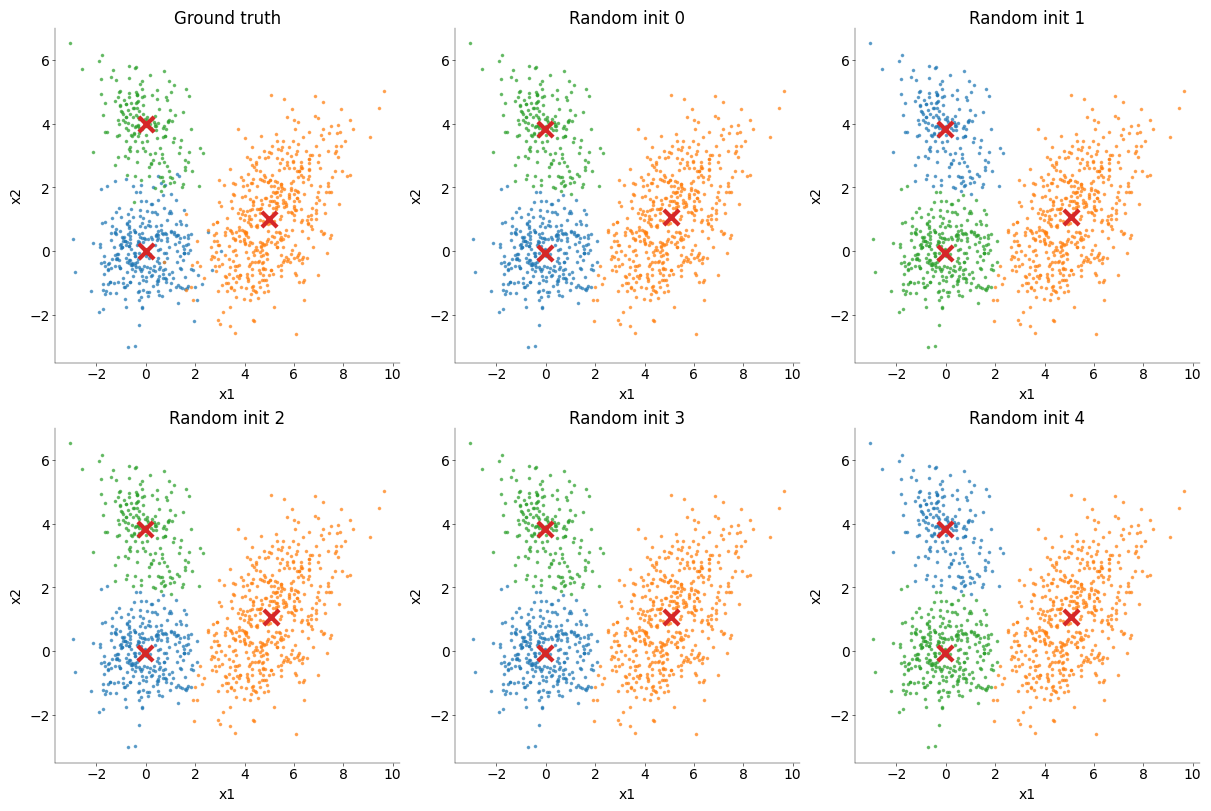

In [37]:
# -------------------------------------------------------------------------
# Run the algorithm with 5 random inits on the toy data, plot and compare original and
# assigned clusters and answer the questions (1+1 pts)
# -------------------------------------------------------------------------

fig, axes = plt.subplots(2, 3, figsize=(12, 8), layout="constrained")
axes = axes.ravel()

# ground truth
for k in range(3):
    axes[0].scatter(
        x[labels == k, 0], x[labels == k, 1], s=10, alpha=0.6, label=f"Cluster {k+1}"
    )

axes[0].scatter(m[:, 0], m[:, 1], marker="x", s=120, linewidths=3, label="True means")
axes[0].set_title("Ground truth")
axes[0].set_xlabel("x1")
axes[0].set_ylabel("x2")

# 5 random initializations
for seed in range(5):
    labels_pred, m_fit, S_fit, p_fit = fit_mog(
        x, n_clusters=3, n_iters=50, random_seed=seed, init="random"
    )

    ax_i = axes[seed + 1]

    for k in range(3):
        ax_i.scatter(x[labels_pred == k, 0], x[labels_pred == k, 1], s=10, alpha=0.6)

    ax_i.scatter(m_fit[:, 0], m_fit[:, 1], marker="x", s=120, linewidths=3)
    ax_i.set_title(f"Random init {seed}")
    ax_i.set_xlabel("x1")
    ax_i.set_ylabel("x2")

plt.show()

### Questions

1) Do all runs converge to good solutions? If not, what are possible failure cases and how does the initialisation help?

_Not all runs converge to equally good solutions. While most initializations recover the clusters well, some runs show slightly worse separation, especially when clusters overlap. This happens because the EM algorithm can get stuck in local optima, depending on how the initial means are chosen. If two initial means are placed too close to each other or far from the true cluster centers, the algorithm may converge to a suboptimal solution. A good initialization helps by starting the parameters closer to the true structure of the data, which increases the chances of finding a better clustering._

2) Do you get the same colors (=labels) in your best assignment(s) compared to the groundtruth? Does it have to be that way or not? Why?

_No, the colors (labels) do not necessarily match the ground truth labels, even when the clustering is correct. For example, what is orange in the ground truth may be blue or green in a given run. This is because cluster labels are arbitrary in unsupervised learning. The algorithm may assign different numeric labels to clusters compared to the ground truth, but the grouping of the points can still be correct. What matters is whether the grouping of points is correct, not the specific color assigned to each group._

## Bonus Task (Optional): Mixture of drifting t-distributions

Instead of a simple Gaussian Mixture Model, more advanced algorithms can be implemented.
Implement a basic version of the mixture of drifting t-distributions (follow https://github.com/aecker/moksm/blob/master/MoT_Kalman.pdf).
What is the advantage of that method? You can verify your implementation using toy data, and then try to run it on the dataset below.

_Grading: 2 BONUS Points._


_BONUS Points do not count for this individual coding lab, but sum up to 5% of your **overall coding lab grade**. There are 4 BONUS points across all coding labs._

In [81]:
# YOUR CODE HERE
def fit_mot(
    x: np.ndarray,
    n_clusters: int,
    n_iters: int = 20,
    nu: float = 20.0,  # higher nu = closer to Gaussian, more stable
    random_seed: int = 0,
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """Fit a Mixture of t-distributions using EM.

    Unlike the standard GMM, this model uses t-distributions which have
    heavier tails than Gaussians, making it more robust to outlier spikes.
    The degrees of freedom parameter nu controls the tail heaviness:
    lower nu = heavier tails, nu -> infinity recovers the Gaussian case.

    Parameters
    ----------
    x : np.ndarray, (n_samples, n_dims)
        Input data
    n_clusters : int
        Number of clusters
    n_iters : int
        Number of EM iterations
    nu : float
        Degrees of freedom for the t-distribution. Lower = heavier tails.
        nu -> infinity recovers the Gaussian case.
    random_seed : int
        Random seed for reproducibility

    Returns
    -------
    labels : np.ndarray, (n_samples,)
        Cluster assignments
    m : np.ndarray, (n_clusters, n_dims)
        Final cluster means
    S : np.ndarray, (n_clusters, n_dims, n_dims)
        Cluster covariances
    p : np.ndarray, (n_clusters,)
        Mixture weights
    """
    n_samples, n_dims = x.shape

    km = KMeans(n_clusters=n_clusters, random_state=random_seed, n_init=5)
    km.fit(x)
    m = km.cluster_centers_.copy()
    S = np.array(
        [np.cov(x[km.labels_ == k].T) + 0.1 * np.eye(n_dims) for k in range(n_clusters)]
    )
    p = np.array([np.mean(km.labels_ == k) for k in range(n_clusters)])

    for step in range(n_iters):

        # E step: compute u and r together
        log_r = np.zeros((n_samples, n_clusters))
        u = np.zeros((n_samples, n_clusters))

        for k in range(n_clusters):
            diff = x - m[k]
            S_inv = np.linalg.inv(S[k])
            mahal = np.sum(diff @ S_inv * diff, axis=1)
            u[:, k] = (nu + n_dims) / (nu + mahal)
            sign, logdet = np.linalg.slogdet(S[k])
            log_r[:, k] = (
                np.log(p[k])
                - 0.5 * logdet
                - 0.5 * (nu + n_dims) * np.log(1 + mahal / nu)
            )

        # normalize in log space for numerical stability
        log_r -= log_r.max(axis=1, keepdims=True)
        r = np.exp(log_r)
        r /= r.sum(axis=1, keepdims=True)

        # M step using u from E step
        Nk = r.sum(axis=0)
        p = Nk / n_samples

        for k in range(n_clusters):
            w = r[:, k] * u[:, k]  # use E-step u, not recomputed
            w_sum = w.sum()
            if w_sum < 1e-10:
                continue
            m[k] = (w[:, None] * x).sum(axis=0) / w_sum
            diff = x - m[k]
            S[k] = (w[:, None] * diff).T @ diff / Nk[k]  # divide by Nk not w_sum
            S[k] += 0.1 * np.eye(n_dims)

    labels = np.argmax(r, axis=1)
    return labels, m, S, p

In [82]:
# Test on toy data
abels_mot, m_mot, S_mot, p_mot = fit_mot(
    x, n_clusters=3, n_iters=30, nu=20.0, random_seed=0
)
print("Cluster sizes:", np.bincount(labels_mot))

Cluster sizes: [193 495 312]


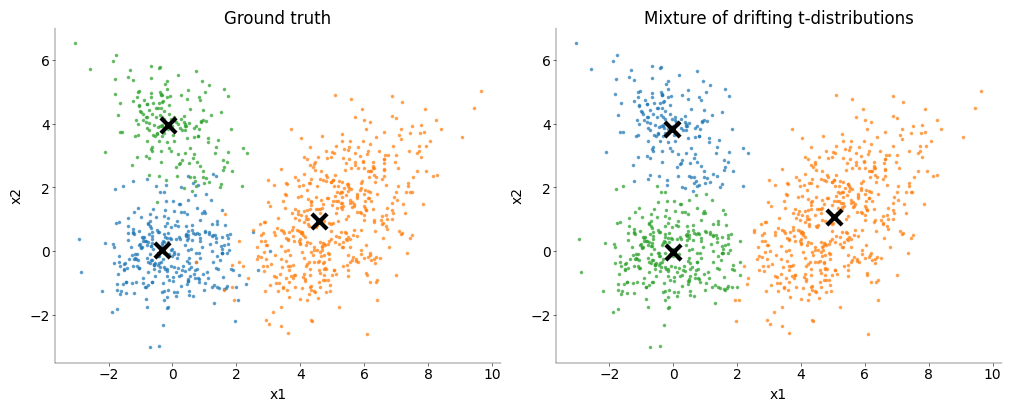

In [83]:
# Plot
fig, axes = plt.subplots(1, 2, figsize=(10, 4), layout="constrained")

# Ground truth
for k in range(3):
    axes[0].scatter(x[labels == k, 0], x[labels == k, 1], s=10, alpha=0.6)
axes[0].scatter(m[:, 0], m[:, 1], marker="x", s=120, linewidths=3, color="black")
axes[0].set_title("Ground truth")
axes[0].set_xlabel("x1")
axes[0].set_ylabel("x2")

# MoT result
for k in range(3):
    axes[1].scatter(x[labels_mot == k, 0], x[labels_mot == k, 1], s=10, alpha=0.6)
axes[1].scatter(
    m_mot[:, 0], m_mot[:, 1], marker="x", s=120, linewidths=3, color="black"
)
axes[1].set_title("Mixture of drifting t-distributions")
axes[1].set_xlabel("x1")
axes[1].set_ylabel("x2")

plt.show()

The Mixture of t-distributions recovers the three clusters successfully, with cluster means close to the ground truth. Compared to the standard GMM, the key advantage is robustness to outliers: the t-distribution has heavier tails, so points far from the cluster center are automatically downweighted through the per-point weights `u` in the EM algorithm, rather than pulling the mean toward them. This is particularly useful in spike sorting, where outlier waveforms (due to noise, overlapping spikes, or artifacts) are common and can distort GMM cluster estimates. A second advantage is that the degrees of freedom parameter `nu` gives explicit control over tail heaviness; setting `nu` large recovers Gaussian behavior, while small `nu` makes the model increasingly robust.

## Task 3: Model complexity
A priori we do not know how many neurons we recorded. Extend your algorithm with an automatic procedure to select the appropriate number of mixture components (clusters). Base your decision on the Bayesian Information Criterion:

$BIC = -2L+P \log N,$

where $L$ is the log-likelihood of the data under the best model, $P$ is the number of parameters of the model and $N$ is the number of data points. You want to minimize the quantity. Plot the BIC as a function of mixture components. What is the optimal number of clusters on the toy dataset?

You can also use the BIC to make your algorithm robust against suboptimal solutions due to local minima. Start the algorithm multiple times and pick the best solutions. You will notice that this depends a lot on which initialization strategy you use.

*Grading: 5 pts*



### Question (0.5 pts)

1) What is the number of parameters of the model? Explain your derivation?


For a Gaussian mixture model with $K$ clusters and $D$ dimensions, the total number of parameters is composed of three parts:

- Each cluster has a mean vector with $D$ parameters, giving $K \cdot D$ parameters.
- Each cluster has a covariance matrix. Since covariance matrices are symmetric, each has $\frac{D(D+1)}{2}$ parameters, giving $K \cdot \frac{D(D+1)}{2}$ parameters.
- The mixture weights contribute $K - 1$ parameters, since they must sum to 1.

Therefore, the total number of parameters is:

$$
P = K D + K \frac{D(D+1)}{2} + (K - 1)
$$

For the toy dataset where $D = 2$, this becomes:

$$
P = 2K + 3K + (K - 1) = 6K - 1
$$

In [39]:
def mog_bic(
    x: np.ndarray, m: np.ndarray, S: np.ndarray, p: np.ndarray
) -> tuple[float, float]:
    """Compute the BIC for a fitted Mixture of Gaussian model

    Parameters
    ----------

    x: np.array, (n_samples, n_dims)
        Input data

    m: np.array, (n_clusters, n_dims)
        Means

    S: np.array, (n_clusters, n_dims, n_dims)
        Covariances

    p: np.array, (n_clusters, )
        Cluster weights / probablities

    Return
    ------

    bic: float
        BIC

    LL: float
        Log Likelihood
    """

    # -------------------------
    # implement the BIC (1.5 pts)
    # -------------------------
    n_samples, n_dims = x.shape
    n_clusters = m.shape[0]

    likelihood = np.zeros(n_samples)  # likelihood for each data point under the mixture

    for k in range(n_clusters):
        likelihood += p[k] * sp.stats.multivariate_normal.pdf(
            x, mean=m[k], cov=S[k], allow_singular=True
        )

    likelihood = np.maximum(likelihood, 1e-300)

    LL = np.sum(np.log(likelihood))  # log-likelihood

    # number of parameters
    # means: K * D
    # covariances: K * D * (D + 1) / 2
    # weights: K - 1
    P = n_clusters * n_dims + n_clusters * n_dims * (n_dims + 1) / 2 + (n_clusters - 1)

    # BIC
    bic = -2 * LL + P * np.log(n_samples)

    return bic, LL

In [40]:
# ----------------------------------------------------------------------------------------------------------------------
# Compute the BIC for mixture models with different numbers of clusters (e.g., 2 - 6). (0.5 pts)
# Make your _estimate of the BIC_ robust against local minima, regardless of the initialization strategy used (0.5 pts)
# ----------------------------------------------------------------------------------------------------------------------

K = np.arange(2, 7)
num_seeds = 10

BIC = np.zeros((num_seeds, len(K)))
LL = np.zeros((num_seeds, len(K)))

# run mog and BIC multiple times here
for seed in range(num_seeds):
    for j, k in enumerate(K):

        labels_k, m_k, S_k, p_k = fit_mog(
            x,
            n_clusters=k,
            n_iters=50,
            random_seed=seed,
            init="random",
        )

        bic_k, ll_k = mog_bic(x, m_k, S_k, p_k)

        BIC[seed, j] = bic_k
        LL[seed, j] = ll_k

In [41]:
best_BIC = BIC.min(axis=0)
best_LL = LL.max(axis=0)

best_K = K[np.argmin(best_BIC)]

print("Best BIC per K:", best_BIC)
print("Best K:", best_K)

Best BIC per K: [8432.10103341 8249.79369838 8271.85083487 8307.9010729  8335.25053626]
Best K: 3


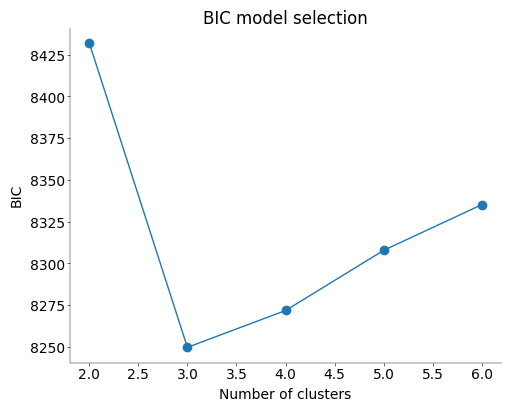

In [42]:
# ------------------------------------------------------------------------------------------
# Plot the result and answer the questions (1+1 pts)
# Don't forget to plot your robust estimate and highlight the estimated number of clusters!
# ------------------------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(5, 4), layout="constrained")

ax.plot(K, best_BIC, marker="o")
ax.set_xlabel("Number of clusters")
ax.set_ylabel("BIC")
ax.set_title("BIC model selection")

plt.show()

The BIC is minimized at 3 clusters, which matches the true number of Gaussian components in the toy dataset. Running several random initializations helps make the estimate more robust, because Expectation Maximization can converge to suboptimal local solutions depending on the starting point.

### Questions

1) What happens to the BIC if the model got stuck in a local minimum? For your reasoning, you can also refer to Task 2.

_If the model gets stuck in a local minimum, the fitted parameters are not optimal, which leads to a worse (lower) likelihood. Since the BIC depends directly on the log-likelihood, this results in a higher BIC value than what we would obtain with a better solution. This is similar to what we observed in `Task 2`, where different initializations led to different clustering results_

2) The goal is to estimate which number of clusters best fits the data using the BIC. Therefore, what qualifies as a robust estimate? Explain your reasoning!
   
_(Hint: think about which number of cluster you would use and why)_

_A robust estimate is one that is stable across multiple runs with different initializations. In practice, this means selecting the number of clusters that consistently gives the lowest BIC across several runs. In this case, `K = 3` is a robust choice because it produces the minimum BIC and aligns with the true structure of the data, even when accounting for variability due to local minima._

Now going back to the number of parameters: since we know that `K = 3`, 

$$
P = 6 \cdot K - 1
$$

$$
P = 6(3) - 1 = 17
$$

$$
\boxed{P = 17}
$$

## Task 4: Spike sorting using Mixture of Gaussian 
Run the full algorithm on your set of extracted features (MoG fitting + model complexity selection).

Show the plot of the BIC as a function of the number of mixture components on the real data, highlight the robust estimate and based on that the best number of clusters.

For the best model, make scatter plots of the first PCs on all four channels (6 plots). Color-code each data point according to its class label in the model with the optimal number of clusters. In addition, indicate the position (mean) of the clusters in your plot.

*Grading: 3 pts*


In [43]:
# -------------------------------------------------------------
# Run the algorithm on the set of extracted features (0.5 pts)
# -------------------------------------------------------------

K = np.arange(2, 16)
num_seeds = 5

BIC = np.zeros((num_seeds, len(K)))
LL = np.zeros((num_seeds, len(K)))

models = {}

for seed in range(num_seeds):
    for j, k in enumerate(K):

        labels_k, m_k, S_k, p_k = fit_mog(
            b,
            n_clusters=k,
            n_iters=50,
            random_seed=seed,
            init="random",
        )

        bic_k, ll_k = mog_bic(b, m_k, S_k, p_k)

        BIC[seed, j] = bic_k
        LL[seed, j] = ll_k

        models[(seed, k)] = {
            "labels": labels_k,
            "m": m_k,
            "S": S_k,
            "p": p_k,
            "bic": bic_k,
            "ll": ll_k,
        }

In [44]:
best_BIC = BIC.min(axis=0)
best_seed_idx = BIC.argmin(axis=0)

best_k_idx = np.argmin(best_BIC)
best_K = K[best_k_idx]
best_seed = best_seed_idx[best_k_idx]

best_model = models[(best_seed, best_K)]

print("Best K:", best_K)
print("Best seed:", best_seed)
print("Best BIC:", best_model["bic"])

Best K: 11
Best seed: 0
Best BIC: 2692026.403316865


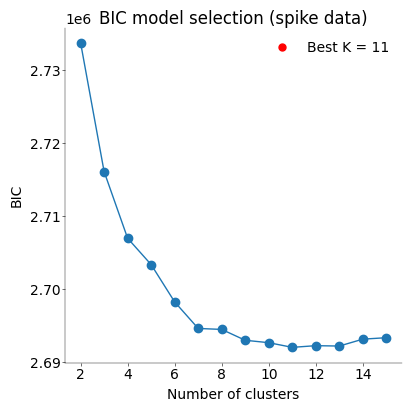

In [45]:
# ----------------------------------------------------------------------------------------------------------------------
# Plot the BIC over number of mixture components and highlight robust estimate and optimal number of clusters (0.5 pts)
# ----------------------------------------------------------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(4, 4))

# BIC curve
ax.plot(K, best_BIC, marker="o")

# best K
best_idx = np.argmin(best_BIC)
ax.scatter(
    K[best_idx], best_BIC[best_idx], color="red", s=100, label=f"Best K = {best_K}"
)

# labels
ax.set_xlabel("Number of clusters")
ax.set_ylabel("BIC")
ax.set_title("BIC model selection (spike data)")

ax.legend()

plt.show()

Refit model with lowest BIC and plot data points

In [46]:
print(f"lowest BIC: cluster = {best_K}")

a = best_model["labels"]
m_best = best_model["m"]
S_best = best_model["S"]
p_best = best_model["p"]

lowest BIC: cluster = 11


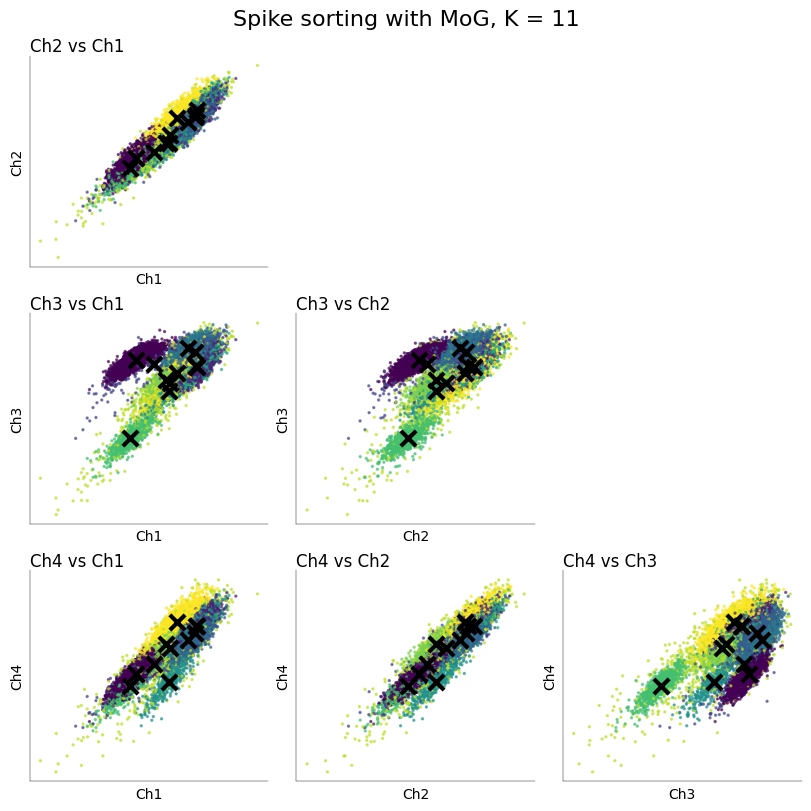

In [47]:
# ------------------------------------------------------------------------------------------------------------------
# Create scatterplots of the first PCs under the best model for all pairwise combinations of the 4 channels. (1 pt)
# ------------------------------------------------------------------------------------------------------------------
mosaic = [
    ["Ch2 vs Ch1", ".", "."],
    ["Ch3 vs Ch1", "Ch3 vs Ch2", "."],
    ["Ch4 vs Ch1", "Ch4 vs Ch2", "Ch4 vs Ch3"],
]

fig, ax = plt.subplot_mosaic(
    mosaic=mosaic, figsize=(8, 8), layout="constrained", dpi=100
)

# index of the 1st PC in b
i = {"Ch1": 0, "Ch2": 3, "Ch3": 6, "Ch4": 9}

for mo in np.ravel(mosaic):
    if mo == ".":
        continue

    y_ch, x_ch = mo.split(" vs ")

    # plot spikes colored by assigned cluster
    ax[mo].scatter(b[:, i[x_ch]], b[:, i[y_ch]], c=a, s=8, alpha=0.6)

    # plot cluster means
    ax[mo].scatter(
        m_best[:, i[x_ch]],
        m_best[:, i[y_ch]],
        marker="x",
        s=120,
        linewidths=3,
        color="black",
    )

    ax[mo].set_xlabel(x_ch)
    ax[mo].set_ylabel(y_ch)
    ax[mo].set_title(mo, loc="left")
    ax[mo].set_xticks([])
    ax[mo].set_yticks([])

fig.suptitle(f"Spike sorting with MoG, K = {best_K}", fontsize=16)
plt.show()

The BIC is minimized at `K = 11`, suggesting this is the best balance between model fit and complexity. The scatter plots show some grouping structure, with the model identifying several regions in the data, but the clusters are still elongated and overlapping rather than clearly separated. This indicates that while `K = 11` captures meaningful structure, the separation between clusters is not fully distinct and the features only partially distinguish the underlying spike sources.

## Task 5: Cluster separation and Correlograms

As postprocessing, implement the calculation of auto- and cross correlograms over the spike times.

Plot the (auto-/cross-) correlograms, displaying a time frame of -30ms to +30ms. Choose a good bin size and interprete the resulting diagrams.

_Grading: 3 pts_

#### Hints

_It is faster to calculate the histogram only over the spiketimes that are in the displayed range. Filter the spike times before calculating the histogram!_

_For the autocorrelogram, make sure not to include the time difference between a spike and itself (which would be exactly 0)_

_For the correlogram an efficient implementation is very important - looping over all spike times is not feasible. Instead, make use of numpy vectorization and broadcasting - you can use functions such as tile or repeat._

In [ ]:
# ----------------------------------------------------------------------
# Implement a function for calculating the spike time differences (1pt)
# ----------------------------------------------------------------------
def cross_time_diff(spiketimes1: np.ndarray, spiketimes2: np.ndarray) -> np.ndarray:
    """Compute the pairwise time differences between two sets of spike times.

    Parameters
    ----------
    spiketimes1: np.ndarray, (n_spikes1, )
        Spike times of the first cluster
    spiketimes2: np.ndarray, (n_spikes2, )
        Spike times of the second cluster

    Return
    ------

    time_diff: np.ndarray, (n_spikes1, n_spikes2)
        Pairwise time differences between the two sets of spike times
        (i.e., spiketimes1[i] - spiketimes2[j])
    """
    # reshaping for broadcasting
    t1 = spiketimes1[:, None]
    t2 = spiketimes2[None, :]
    time_diff = t1 - t2  # pairwise difference

    return time_diff

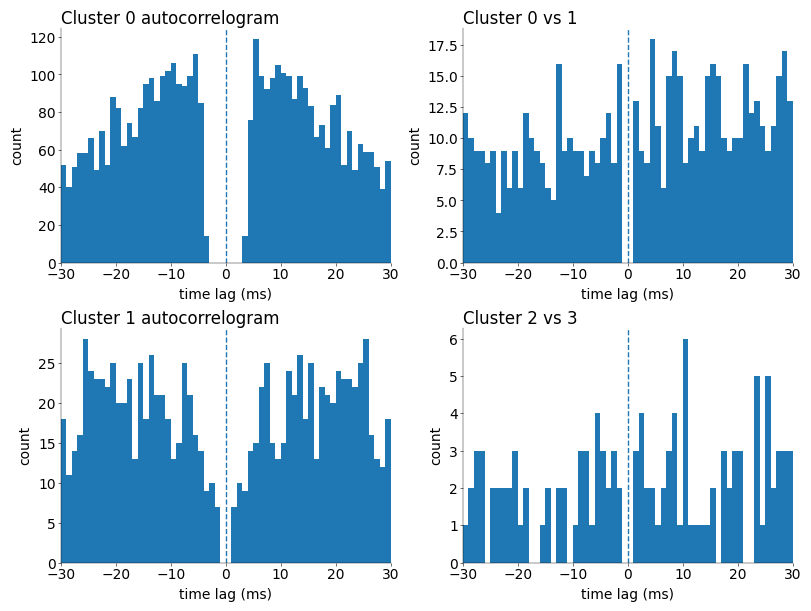

In [62]:
# -----------------------------------------------------------------------------------
# Calculate and plot auto- and cross correlograms and answer the questions (1+1 pts)
# -----------------------------------------------------------------------------------

# use cluster labels from best model
labels_best = a

# spike times in ms
labels_best = a

# use actual detected spike times in ms
spike_s = np.load("../data/nds_cl_1_spiketimes_s.npy")
spike_t = t[spike_s] * 1000
# correlogram settings
max_lag = 30  # ms
bin_size = 1  # ms
bins = np.arange(-max_lag, max_lag + bin_size, bin_size)

# choose a few clusters to inspect
clusters = np.unique(labels_best)
clusters = clusters[:4]  # plot first 4 clusters to keep it readable

mosaic = [
    ["C0 auto", "C0-C1"],
    ["C1 auto", "C2-C3"],
]

fig, ax = plt.subplot_mosaic(
    mosaic=mosaic, figsize=(8, 6), layout="constrained", dpi=100
)


# helper function
def plot_correlogram(ax_, spk1, spk2, title, auto=False):
    dt = cross_time_diff(spk1, spk2).ravel()

    # keep only displayed range
    dt = dt[(dt >= -max_lag) & (dt <= max_lag)]

    # remove zero-lag self comparisons for autocorrelogram
    if auto:
        dt = dt[dt != 0]

    ax_.hist(dt, bins=bins)
    ax_.axvline(0, linestyle="--")
    ax_.set_xlim(-max_lag, max_lag)
    ax_.set_xlabel("time lag (ms)")
    ax_.set_ylabel("count")
    ax_.set_title(title, loc="left")


# cluster spike times
spk = {c: spike_t[labels_best == c] for c in clusters}

# make sure we have enough clusters
plot_correlogram(
    ax["C0 auto"],
    spk[clusters[0]],
    spk[clusters[0]],
    f"Cluster {clusters[0]} autocorrelogram",
    auto=True,
)

plot_correlogram(
    ax["C1 auto"],
    spk[clusters[1]],
    spk[clusters[1]],
    f"Cluster {clusters[1]} autocorrelogram",
    auto=True,
)

plot_correlogram(
    ax["C0-C1"],
    spk[clusters[0]],
    spk[clusters[1]],
    f"Cluster {clusters[0]} vs {clusters[1]}",
    auto=False,
)

plot_correlogram(
    ax["C2-C3"],
    spk[clusters[2]],
    spk[clusters[3]],
    f"Cluster {clusters[2]} vs {clusters[3]}",
    auto=False,
)

plt.show()

### Questions
1) Based on the plot, do you see clusters that contain spikes likely from a single neuron?

_Cluster 0 shows the clearest evidence of a single neuron — the autocorrelogram has a visible dip around 0 ms and a relatively smooth shape overall. This refractory period dip suggests the spikes are coming from one well-isolated unit._

2) Do you see cases where plural clusters might come from the same neuron?

_TClusters 2 and 3 might come from the same neuron — their cross-correlogram (bottom right) is very noisy and sparse with very low counts, suggesting these clusters have very few spikes overall and may be fragments of the same unit that got split during sorting._

3) Do you see clusters that might contain spikes from plural neurons?

_Cluster 1's autocorrelogram looks noisy and irregular with no clear refractory period dip, and the counts are relatively low and variable. This suggests it may be a "multi-unit" cluster containing spikes from more than one neuron, since a true single unit should show a cleaner dip at 0 ms._

4) Explain the term "refractory period" and how one can see it in this plot.

_The refractory period is the brief window `(~1–2 ms)` after a neuron fires during which the sodium channels are inactivated and the neuron cannot fire again. In the autocorrelogram, this appears as a gap or dip near `0 ms`; if a cluster is a true single neuron, you should see almost no spike pairs at very short time lags. Cluster 0 shows this most clearly._